In [5]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import sys
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import pickle

sys.path.insert(0, 'src')
from grn import grn

In [6]:
with open("../graph.cfg10.rep1.r2.dout3.din100.seed1001.gpickle", 'rb') as f:
    G = pickle.load(f)

## G2: manually adjusted GRN

In [7]:
# manually adjust GRN hyperparameters in an attempt to build GRN with more non-additive effects
np.random.seed(5)
G2 = grn().add_structure(
    n=256,
    k=1,
    alpha=1e-99,
    beta=0.99,       # 1 - 1/r
    gamma=0.01,      # 1/r
    kappa=10,        # --w
    delta_in=100,
    delta_out=100,
)

G2.simulate_rna(
    s=1e-4,
    dt=1e-2,
    tmax=20000,
    burnin=5000,
    tol=1e-3,
    save=False,
)

array([[4.84649231e-10, 4.18872025e-01, 3.77322668e-03, 1.69880546e-10,
        1.06239300e+00, 3.58549281e-07, 5.00508449e-07, 1.01727610e+00,
        9.22185642e-05, 1.12122699e+00, 2.52883912e-02, 1.08584806e+00,
        1.25280245e-09, 1.20867685e+00, 1.53776463e+00, 1.08056495e-08,
        1.55010171e-04, 1.83459186e-06, 1.09137161e+00, 1.06043472e-09,
        1.08336101e+00, 8.00775265e-03, 1.21524535e+00, 2.25520557e-09,
        9.16532224e-03, 1.34900708e+00, 1.06786693e+00, 8.67781628e-01,
        8.78636767e-02, 1.01295853e+00, 8.87810232e-10, 1.04249830e+00,
        1.02088890e+00, 1.16010403e+00, 3.11985535e-03, 9.27389566e-01,
        1.93303618e-09, 9.72905997e-01, 1.06724803e+00, 1.32670786e-08,
        1.97531781e-03, 1.81200185e-01, 3.82578343e-04, 1.23273126e-06,
        1.06109423e+00, 1.41638243e+00, 1.19667148e+00, 9.15270357e-02,
        1.13071151e+00, 1.03317256e+00, 3.75856888e-07, 1.01290271e+00,
        1.08133226e+00, 1.20993819e+00, 1.05294511e+00, 1.630200

## G3: second manually adjusted GRN

In [8]:
# Same random seed as G2, reset before generating G3
np.random.seed(5)
G3 = grn().add_structure(
    n=256,
    k=1,
    alpha=1e-99,
    beta=0.75,       # 1 - 1/r
    gamma=0.25,      # 1/r
    kappa=10,        # --w
    delta_in=100,
    delta_out=1,
)

G3.simulate_rna(
    s=1e-4,
    dt=1e-2,
    tmax=20000,
    burnin=5000,
    tol=1e-3,
    save=False,
)

array([[0.40134766, 0.52113436, 0.41345122, 0.55423591, 0.24940203,
        0.00824444, 0.7499939 , 0.05158365, 0.34878561, 0.24131589,
        0.10210803, 0.42921168, 0.43213425, 0.17597388, 0.50327465,
        0.0090051 , 0.84216039, 0.43807547, 0.08892712, 0.00517759,
        0.15249503, 0.00826165, 0.03296733, 0.35410256, 0.025503  ,
        0.02003108, 0.62896421, 0.09378358, 0.37294875, 0.01978424,
        0.26145216, 0.52016119, 0.55319635, 0.59044607, 0.34743717,
        0.21467853, 0.80743297, 0.2937654 , 0.07668098, 0.0138034 ,
        0.41741296, 0.0071455 , 0.32524356, 0.38381767, 0.07250683,
        0.44120831, 0.20507611, 0.00378403, 0.0889725 , 0.05392258,
        0.02707397, 0.19675887, 0.96476643, 0.57437545, 0.02445512,
        0.83692191, 0.02542303, 0.48768259, 0.22263909, 0.0725727 ,
        0.06521748, 0.82519536, 0.1272956 , 0.20865251, 0.25144698,
        0.28727185, 0.09699723, 0.21344278, 0.0803279 , 0.04291328,
        0.29524823, 0.35575755, 0.13498879, 0.01

## Original GRN: G

In [9]:
single_ko_expression = np.zeros((G.n, G.n))
single_ko_logfc = np.zeros((G.n, G.n))
single_ko_convergence = {}

for gene in tqdm(range(G.n), desc="Simulating single-gene KOs"):
    
    result = G.ko_nodes(
        genes=[gene],
        stats=("new_rna", 'logfc', 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )
    
    single_ko_expression[gene, :] = result["new_rna"].flatten()
    single_ko_logfc[gene, :] = result["logfc"].flatten()
    single_ko_convergence[gene] = result['convergence']
x_single_ko = np.eye(G.n)
y_single_ko = single_ko_expression

Simulating single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

In [10]:
pairs = list(combinations(range(G.n), 2))

n_jobs = 16

def run_double_ko(pair):
    a, b = pair

    result = G.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc", 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
        np.asarray(result['convergence'])
    )


results = Parallel(
    n_jobs=16,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko)(pair)
    for pair in pairs
)

double_expression = np.asarray(
    [r[0] for r in results],
    dtype=np.float32
)

double_logfc = np.asarray(
    [r[1] for r in results],
    dtype=np.float32
)
double_convergence = np.asarray(
    [r[2] for r in results],
    dtype=np.float32
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 tasks      | elapsed:    3.3s
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    3.3s
[Parallel(n_jobs=16)]: Done  16 tasks      | elapsed:    3.3s
[Parallel(n_jobs=16)]: Done  25 tasks      | elapsed:    3.6s
[Parallel(n_jobs=16)]: Done  34 tasks      | elapsed:    3.8s
[Parallel(n_jobs=16)]: Done  45 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done  56 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done  69 tasks      | elapsed:    4.5s
[Parallel(n_jobs=16)]: Done  82 tasks      | elapsed:    4.8s
[Parallel(n_jobs=16)]: Done  97 tasks      | elapsed:    5.0s
[Parallel(n_jobs=16)]: Done 112 tasks      | elapsed:    5.3s
[Parallel(n_jobs=16)]: Done 129 tasks      | elapsed:    5.6s
[Parallel(n_jobs=16)]: Done 146 tasks      | elapsed:    5.9s
[Parallel(n_jobs=16)]: Done 165 tasks      | elapsed:    6.3s
[Parallel(n_jobs=16)]: Done 184 tasks      | elapsed:  

In [12]:
pairs = np.asarray(pairs, dtype=int)
# Extract the single KO logFC values for genes A and B in each pair
single_a = single_ko_logfc[pairs[:, 0], :]
single_b = single_ko_logfc[pairs[:, 1], :]

# Calculate the expected additive effect
expected_additive = single_a + single_b

# The nonadditiveness (interaction residuals) is the difference 
# between the actual double KO logFC and the additive expectation
interaction_residuals = double_logfc - expected_additive

# Flatten into a 1D array to prepare for histograms/quantiles
errors = interaction_residuals.ravel()

# Filter out any infinite values (in case zero expression produced infinite logFC)
errors = errors[np.isfinite(errors)]

# Verification prints matching your V3 format
print("double KO:", double_logfc.shape)
print("additive expectation:", expected_additive.shape)
print("interaction residuals:", interaction_residuals.shape)
print("Number of valid residuals:", len(errors))

double KO: (32640, 256)
additive expectation: (32640, 256)
interaction residuals: (32640, 256)
Number of valid residuals: 8355840


## G2: single and double KOs

In [13]:
single_ko_expression_G2 = np.zeros((G2.n, G2.n))
single_ko_logfc_G2 = np.zeros((G2.n, G2.n))
single_ko_convergence_G2 = {}

for gene in tqdm(range(G2.n), desc="Simulating single-gene KOs"):
    
    result = G2.ko_nodes(
        genes=[gene],
        stats=("new_rna", 'logfc', 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )
    
    single_ko_expression_G2[gene, :] = result["new_rna"].flatten()
    single_ko_logfc_G2[gene, :] = result["logfc"].flatten()
    single_ko_convergence_G2[gene] = result['convergence']
x_single_ko_G2 = np.eye(G2.n)
y_single_ko_G2 = single_ko_expression_G2

Simulating single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

In [14]:
pairs = list(combinations(range(G2.n), 2))

n_jobs = 16

def run_double_ko_G2(pair):
    a, b = pair

    result = G2.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc", 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
        np.asarray(result['convergence'])
    )


results_G2 = Parallel(
    n_jobs=16,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko_G2)(pair)
    for pair in pairs
)

double_expression_G2 = np.asarray(
    [r[0] for r in results_G2],
    dtype=np.float32
)

double_logfc_G2 = np.asarray(
    [r[1] for r in results_G2],
    dtype=np.float32
)
double_convergence_G2 = np.asarray(
    [r[2] for r in results_G2],
    dtype=np.float32
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done  16 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done  25 tasks      | elapsed:    4.7s
[Parallel(n_jobs=16)]: Done  34 tasks      | elapsed:    5.1s
[Parallel(n_jobs=16)]: Done  45 tasks      | elapsed:    5.5s
[Parallel(n_jobs=16)]: Done  56 tasks      | elapsed:    5.8s
[Parallel(n_jobs=16)]: Done  69 tasks      | elapsed:    6.3s
[Parallel(n_jobs=16)]: Done  82 tasks      | elapsed:    6.8s
[Parallel(n_jobs=16)]: Done  97 tasks      | elapsed:    7.3s
[Parallel(n_jobs=16)]: Done 112 tasks      | elapsed:    7.9s
[Parallel(n_jobs=16)]: Done 129 tasks      | elapsed:    8.5s
[Parallel(n_jobs=16)]: Done 146 tasks      | elapsed:    9.0s
[Parallel(n_jobs=16)]: Done 165 tasks      | elapsed:    9.8s
[Parallel(n_jobs=16)]: Done 184 tasks      | elapsed:  

In [15]:
pairs = np.asarray(pairs, dtype=int)
# Extract the single KO logFC values for genes A and B in each pair
single_a_G2 = single_ko_logfc_G2[pairs[:, 0], :]
single_b_G2 = single_ko_logfc_G2[pairs[:, 1], :]

# Calculate the expected additive effect
expected_additive_G2 = single_a_G2 + single_b_G2

# The nonadditiveness (interaction residuals) is the difference 
# between the actual double KO logFC and the additive expectation
interaction_residuals_G2 = double_logfc_G2 - expected_additive_G2

# Flatten into a 1D array to prepare for histograms/quantiles
errors_G2 = interaction_residuals_G2.ravel()

# Filter out any infinite values (in case zero expression produced infinite logFC)
errors_G2 = errors_G2[np.isfinite(errors_G2)]

# Verification prints matching your V3 format
print("double KO:", double_logfc_G2.shape)
print("additive expectation:", expected_additive_G2.shape)
print("interaction residuals:", interaction_residuals_G2.shape)
print("Number of valid residuals:", len(errors_G2))

double KO: (32640, 256)
additive expectation: (32640, 256)
interaction residuals: (32640, 256)
Number of valid residuals: 8355840


## G3: single and double KOs

In [16]:
single_ko_expression_G3 = np.zeros((G3.n, G3.n))
single_ko_logfc_G3 = np.zeros((G3.n, G3.n))
single_ko_convergence_G3 = {}

for gene in tqdm(range(G3.n), desc="Simulating single-gene KOs"):
    
    result = G3.ko_nodes(
        genes=[gene],
        stats=("new_rna", 'logfc', 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )
    
    single_ko_expression_G3[gene, :] = result["new_rna"].flatten()
    single_ko_logfc_G3[gene, :] = result["logfc"].flatten()
    single_ko_convergence_G3[gene] = result['convergence']
x_single_ko_G3 = np.eye(G3.n)
y_single_ko_G3 = single_ko_expression_G3

Simulating single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

In [17]:
pairs = list(combinations(range(G3.n), 2))

n_jobs = 16

def run_double_ko_G3(pair):
    a, b = pair

    result = G3.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc", 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
        np.asarray(result['convergence'])
    )


results_G3 = Parallel(
    n_jobs=16,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko_G3)(pair)
    for pair in pairs
)

double_expression_G3 = np.asarray(
    [r[0] for r in results_G3],
    dtype=np.float32
)

double_logfc_G3 = np.asarray(
    [r[1] for r in results_G3],
    dtype=np.float32
)
double_convergence_G3 = np.asarray(
    [r[2] for r in results_G3],
    dtype=np.float32
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done  16 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done  25 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done  34 tasks      | elapsed:    0.8s
[Parallel(n_jobs=16)]: Done  45 tasks      | elapsed:    0.9s
[Parallel(n_jobs=16)]: Done  56 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  69 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  82 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done  97 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 112 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done 129 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 146 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 165 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 184 tasks      | elapsed:  

In [18]:
pairs = np.asarray(pairs, dtype=int)
# Extract the single KO logFC values for genes A and B in each pair
single_a_G3 = single_ko_logfc_G3[pairs[:, 0], :]
single_b_G3 = single_ko_logfc_G3[pairs[:, 1], :]

# Calculate the expected additive effect
expected_additive_G3 = single_a_G3 + single_b_G3

# The nonadditiveness (interaction residuals) is the difference 
# between the actual double KO logFC and the additive expectation
interaction_residuals_G3 = double_logfc_G3 - expected_additive_G3

# Flatten into a 1D array to prepare for histograms/quantiles
errors_G3 = interaction_residuals_G3.ravel()

# Filter out any infinite values (in case zero expression produced infinite logFC)
errors_G3 = errors_G3[np.isfinite(errors_G3)]

# Verification prints matching your V3 format
print("double KO:", double_logfc_G3.shape)
print("additive expectation:", expected_additive_G3.shape)
print("interaction residuals:", interaction_residuals_G3.shape)
print("Number of valid residuals:", len(errors_G3))

double KO: (32640, 256)
additive expectation: (32640, 256)
interaction residuals: (32640, 256)
Number of valid residuals: 8355840


## Overlaid histogram: G, G2, G3

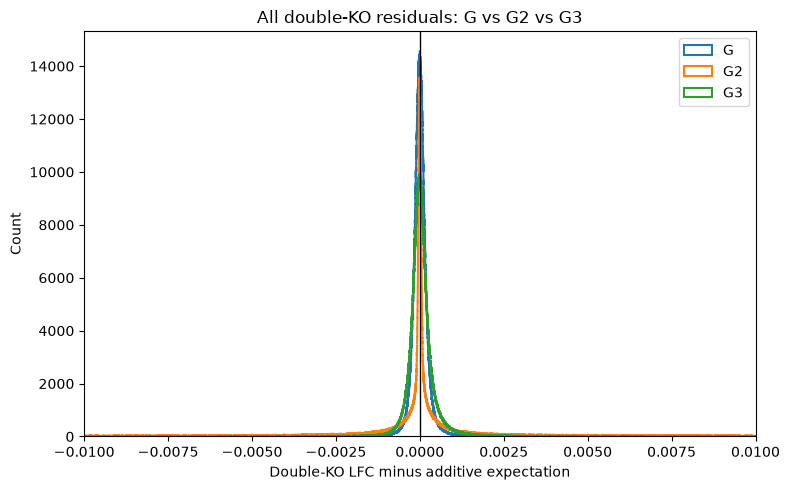

In [19]:
# Shared bins within the plotted range make the histograms comparable.
common_bins = np.linspace(-0.01, 0.01, 30001)  # Original notebook used 30000 bins

plt.figure(figsize=(8, 5))

plt.hist(errors, bins=common_bins, histtype='step', linewidth=1.5, label='G')
plt.hist(errors_G2, bins=common_bins, histtype='step', linewidth=1.5, label='G2')
plt.hist(errors_G3, bins=common_bins, histtype='step', linewidth=1.5, label='G3')

plt.axvline(0, linewidth=1, color='black')
plt.xlim(-0.01, 0.01)

plt.xlabel('Double-KO LFC minus additive expectation')
plt.ylabel('Count')
plt.title('All double-KO residuals: G vs G2 vs G3')
plt.legend()

plt.tight_layout()
plt.show()

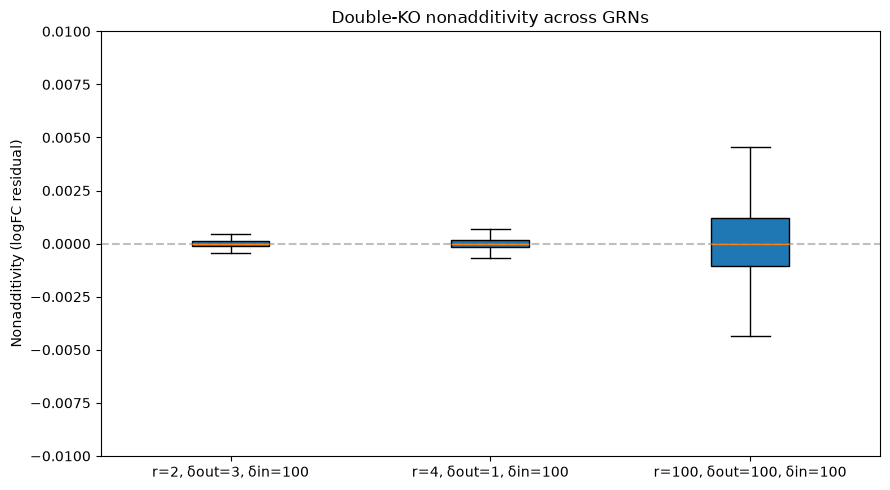

In [27]:
plt.figure(figsize=(9, 5))

plt.boxplot(
    [errors, errors_G3, errors_G2],
    tick_labels=[
        'r=2, δout=3, δin=100',
        'r=4, δout=1, δin=100',
        'r=100, δout=100, δin=100'
    ],
    showfliers=False,
    patch_artist=True
)

plt.ylabel('Nonadditivity (logFC residual)')
plt.title('Double-KO nonadditivity across GRNs')
plt.ylim(-0.01, 0.01)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(
    'double_KO_nonadditivity_boxplot.png',
    dpi=600,
    bbox_inches='tight'
)


In [26]:
plt.savefig(
    'double_KO_nonadditivity_boxplot.png',
    dpi=600,
    bbox_inches='tight'
)
plt.show()

<Figure size 640x480 with 0 Axes>